## Réseau cristallin du $\text{NaNO}_2$

- BODART Quentin - 70362100 
- DEJAIE Lisa - 75692300
- STIEVENARD Alexandre - 79822300  
- VAN EETVELDE Eric - 38962300  

#### 1. Imports, téléchargement de la structure et fonctions utiles

In [208]:
### IMPORTS ###
try:
    import py3Dmol
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.patches as pch
    from numpy.linalg import norm
    from mp_api.client import MPRester #Materials Project
    from pymatgen.core import Structure #structure
    from pymatgen.analysis.diffraction.xrd import XRDCalculator # diffraction
    from pymatgen.electronic_structure.plotter import plot_brillouin_zone,BSPlotter # zone de Brillouin, bande électronique
    from pymatgen.electronic_structure.core import Spin #spin
    from pymatgen.phonon.plotter import PhononBSPlotter # bande de phonons
    # from emmet.core.electronic_structure import BSPathType # fix phonon ? nop
    from pymatgen.symmetry.analyzer import SpacegroupAnalyzer #symétrie
    from pymatgen.symmetry.bandstructure import HighSymmKpath # symétrie 



except ImportError as e:
    print(f"module or submodule \"{e.name}\" not found.\
        \nPlease run the following command in the same folder as this notebook to ensure all needed modules are installed:\
        \npip install -r requirements.txt")
    raise SystemExit

In [209]:
### TELECHARGEMENT
mp_key = "cLLBrCi8gU7SqhnPKS4NJqSKB4Y6d0gD"
mp_id = "mp-2964"

with MPRester(mp_key) as mpr: 
    structure = mpr.get_structure_by_material_id(mp_id)
    bandstructure = mpr.get_bandstructure_by_material_id(mp_id,line_mode=True)
    #phonon_doc = mpr.materials.phonon.search(mp_id,fields=["phonon_bandstructure", "phonon_dos"]) essai de fix phonon
    phononbandstructure = mpr.get_phonon_bandstructure_by_material_id(mp_id) # fonctionne mais permet pas de plot
    phononDOS = mpr.get_phonon_dos_by_material_id(mp_id) # pour plus tard

sga = SpacegroupAnalyzer(structure)

Retrieving ElectronicStructureDoc documents: 100%|██████████| 1/1 [00:00<00:00, 25115.59it/s]


In [210]:
### FONCTIONS ###
def print_title(title:str):
    print('\n' + title + '\n' + "-"*len(title))

def get_angle(v1:np.ndarray, v2:np.ndarray) -> float:
    """Retourne l'angle en degrés entre deux vecteurs 3D"""
    return np.rad2deg(np.arccos(np.dot(v1,v2) / (norm(v1)*norm(v2))))

def py3Dmol_visualise(structure:Structure):
    """Crée une fenêtre de visualisation interactive de la structure donnée"""
    view = py3Dmol.view(
        width=700, 
        height=500,
        data=structure.to(fmt="cif"),
        format="cif",
        style={"sphere": {"scale": 0.3}, "stick": {"radius": 0.1}}
    )
    view.addUnitCell()
    view.zoomTo()
    view.show()

#### 2. Vecteurs de bases, type de maille, système cristallin et  groupe ponctuel

##### 2.1 Visualisation 

2.1.1. Maille primitive

In [211]:
py3Dmol_visualise(structure.to_primitive())

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

2.1.2. Maille conventionelle

In [212]:
py3Dmol_visualise(structure.to_conventional())

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

##### 2.2 Vecteurs de bases 

In [213]:
### FONCTIONS HELPER ###
def lattice_vectors_df(matrix: np.ndarray) -> pd.DataFrame:
    """
    matrix : tableau de taille (3,3) où les lignes correspondent aux vecteurs a, b, c en coordonnées cartésiennes.
    Retourne un DataFrame contenant les composantes et les normes.
    """
    labels = ["a", "b", "c"]
    rows = []
    for i, lab in enumerate(labels):
        vec = matrix[i]
        rows.append({
            "vecteur": lab,
            "x": float(vec[0]),
            "y": float(vec[1]),
            "z": float(vec[2]),
            "norme": float(norm(vec)),
        })
    df = pd.DataFrame(rows, columns=["vecteur", "x", "y", "z", "norme"])
    return df

def lattice_angles_df(matrix: np.ndarray) -> pd.DataFrame:
    """
    Calcule alpha = angle(b,c), beta = angle(c,a), gamma = angle(a,b) en degrés
    en utilisant la fonction existante get_angle(v1, v2).
    """
    alpha = get_angle(matrix[1], matrix[2])
    beta  = get_angle(matrix[2], matrix[0])
    gamma = get_angle(matrix[0], matrix[1])
    return pd.DataFrame({
        "angle": ["α", "β", "γ"],
        "valeur (°)": [alpha, beta, gamma]
    })

def show_lattice(title: str, matrix: np.ndarray, precision: int = 2) -> None:
    """
    Affiche un titre puis les DataFrames des vecteurs du réseau (avec leurs normes)
    et des angles associés, avec un arrondi à la précision donnée.
    """
    print_title(title)
    df_vec = lattice_vectors_df(matrix).round(precision)
    df_ang = lattice_angles_df(matrix).round(precision)

    display(df_vec.round(precision))
    display(df_ang.round(precision))

def verify_direct_reciprocal_compatible(direct, reciprocal, tol=1e-9):
    """
    Vérifie que les vecteurs du réseau direct: d1,d2,d3 sont compatibles avec les 
    vecteurs du réseau réciproque: r1,r2,r3 en vérifiant la relation:
        d_i · r_j = 2π * δ_ij

    Paramètres
    ----------
    d1,d2,d3 : array-like (3,)
        Vecteurs du réseau direct.
    r1,r2,r3 : array-like (3,)
        Vecteurs du réseau réciproque.
    tol : float
        Tolérance sur les produits scalaires.
    ----------
    """
    # Construire les matrices (3x3) : chaque ligne est un vecteur
    direct = np.array(direct, dtype=float)
    reciprocal = np.array(reciprocal, dtype=float)

    # Vérifications de forme
    if direct.shape != (3, 3) or reciprocal.shape != (3, 3):
        raise ValueError(
            f"Chaque vecteur doit être de dimension 3. "
            f"Shapes obtenues: direct={direct.shape}, reciprocal={reciprocal.shape}"
        )

    # Matrice des produits scalaires: (i,j) = d_i · r_j
    dot_matrix = direct @ reciprocal.T

    target = 2.0 * np.pi * np.eye(3)
    error_matrix = dot_matrix - target
    max_abs_error = float(np.max(np.abs(error_matrix)))

    ok = bool(max_abs_error <= tol)
    if (ok):
        print("Les vecteurs du réseau direct et réciproque sont compatibles")
        return
    print("Erreur: Les vecteurs du réseau direct et réciproque sont compatibles")
    return

def K_from_hkl(h, k, l, recp_matrix):
    "Récupère le vecteur K du réseau réciproque à partir des indices de miller et de la matrice contenant les vecteurs du réseau réciproque"
    return h * recp_matrix[0] + k * recp_matrix[1] + l * recp_matrix[2]


In [214]:
### RESEAU DIRECT PRIMITIF ###
matrix = np.array(structure.lattice.matrix)
show_lattice("Vecteurs de base du réseau direct de la maille primitive (en Å)", matrix)

### RESEAU RECIPROQUE PRIMITIF ###

recp_matrix = np.array(structure.lattice.reciprocal_lattice.matrix)
show_lattice("Vecteurs de base du réseau réciproque de la maille primitive (en Å⁻¹)", recp_matrix)

verify_direct_reciprocal_compatible(matrix, recp_matrix)


Vecteurs de base du réseau direct de la maille primitive (en Å)
---------------------------------------------------------------


,vecteur,x,y,z,norme
0,a,3.17,-0.00,1.44,3.48
1,b,1.55,3.83,0.80,4.20
2,c,-0.00,-0.01,4.20,4.20


,angle,valeur (°)
0,α,79.16
1,β,65.56
2,γ,65.56



Vecteurs de base du réseau réciproque de la maille primitive (en Å⁻¹)
---------------------------------------------------------------------


,vecteur,x,y,z,norme
0,a,1.98,-0.80,-0.00,2.14
1,b,-0.00,1.64,0.00,1.64
2,c,-0.68,-0.04,1.49,1.64


,angle,valeur (°)
0,α,91.17
1,β,112.06
2,γ,112.06


Les vecteurs du réseau direct et réciproque sont compatibles


In [215]:
### RESEAU DIRECT CONVENTIONNEL ###
matrix = np.array(structure.to_conventional().lattice.matrix)
show_lattice("Vecteurs de base du réseau direct de la maille conventionelle (en Å)", matrix)

### RESEAU RECIPROQUE CONVENTIONNEL ###

recp_matrix = np.array(structure.to_conventional().lattice.reciprocal_lattice.matrix)
show_lattice("Vecteurs de base du réseau réciproque de la maille conventionnelle (en Å⁻¹)", recp_matrix)

verify_direct_reciprocal_compatible(matrix, recp_matrix)


Vecteurs de base du réseau direct de la maille conventionelle (en Å)
--------------------------------------------------------------------


,vecteur,x,y,z,norme
0,a,3.48,0.00,0.00,3.48
1,b,0.00,5.36,0.00,5.36
2,c,0.00,0.00,5.47,5.47


,angle,valeur (°)
0,α,90.0
1,β,90.0
2,γ,90.0



Vecteurs de base du réseau réciproque de la maille conventionnelle (en Å⁻¹)
---------------------------------------------------------------------------


,vecteur,x,y,z,norme
0,a,1.81,-0.00,0.00,1.81
1,b,0.00,1.17,0.00,1.17
2,c,-0.00,-0.00,1.15,1.15


,angle,valeur (°)
0,α,90.0
1,β,90.0
2,γ,90.0


Les vecteurs du réseau direct et réciproque sont compatibles


In [216]:
group_symbol_to_french = {
    "P" : "Primitive",
    "I" : "Centrée",
    "A" : "Bases centrées (A)",
    "B" : "Bases centrées (B)",
    "C" : "Bases centrées (C)",
    "F" : "Faces centrées"
}
crystal_system_to_french = {
    "cubic" : "Cubique",
    "hexagonal" : "Hexagonal",
    "monoclinic" : "Monoclinique",
    "orthorhombic" : "Orthorombique",
    "tetragonal" : "Tétragonal",
    "triclinic" : "Triclinique",
    "trigonal" : "Trigonal"
}

### TYPE DE MAILLE ###
print_title("Type de maille")
print(group_symbol_to_french[sga.get_space_group_symbol()[0]])

### SYSTEME CRYSTALLIN ###
print_title("Système cristallin")
print(crystal_system_to_french[sga.get_crystal_system()])

### GROUPE PONCTUEL ###
print_title("Groupe ponctuel")
print(sga.get_point_group_symbol())


Type de maille
--------------
Centrée

Système cristallin
------------------
Orthorombique

Groupe ponctuel
---------------
mm2


#### Opérations de symmétrie

In [217]:
#### HELPER FUNCTIONS ####
def draw_lattice_axes(ax, origin=(0.05,0.05), length=0.15):
    
    x0, y0 = origin
    
    # a axis
    ax.annotate(
        "", 
        xy=(x0+length, y0), 
        xytext=(x0, y0),
        arrowprops=dict(arrowstyle="->", linewidth=2)
    )
    ax.text(x0+length+0.02, y0, "a", va='center')
    
    # b axis
    ax.annotate(
        "",
        xy=(x0, y0+length),
        xytext=(x0, y0),
        arrowprops=dict(arrowstyle="->", linewidth=2)
    )
    ax.text(x0, y0+length+0.02, "b", ha='center')
    
    # c axis (out of plane)
    ax.text(x0-0.01, y0-0.03, "⊙ c")

Le groupe ponctel: mm2

Dans un systeme orthorombique, en suivant la notation de Hermann-Mauguin, les trois caractères décrivent la symétrie le long des trois axes $a,b$ et $c$.

Nous avons donc:
- Une réflexion de normale $a$
- Une réflexion de normale $b$
- Un axe de rotation d'ordre 2 le long de $c$



In [218]:
conventional = sga.get_conventional_standard_structure() 

# Récupération de la position des atomes dans la maille conventionelle
atoms_conv = []

for site in conventional:
    x, y, z = site.frac_coords 
    atoms_conv.append({
        "element": site.specie.symbol,
        "pos": (x, y, z)
    })

print_title("Atomes dans la cellule conventionelle")
for i, atom in enumerate(atoms_conv):
    x, y, z = atom["pos"]
    print(f"{i:2d} | {atom['element']:2s} | ({x:.8f}, {y:.8f}, {z:.8f})")


Atomes dans la cellule conventionelle
-------------------------------------
 0 | Na | (0.50000000, 0.50000000, 0.08675079)
 1 | Na | (0.00000000, 0.00000000, 0.58675079)
 2 | N  | (0.50000000, 0.50000000, 0.62519484)
 3 | N  | (0.00000000, 0.00000000, 0.12519484)
 4 | O  | (0.00000000, 0.19829721, 0.99957718)
 5 | O  | (0.00000000, 0.80170279, 0.99957718)
 6 | O  | (0.50000000, 0.69829721, 0.49957718)
 7 | O  | (0.50000000, 0.30170279, 0.49957718)


##### Réflexion de normale a:
$$ (x,y,z) \rightarrow (\bar{x},y,z) $$

Nous montrons l'effet de cette opération sur le **Na** (#0)  situé en:
\begin{equation}
    \begin{bmatrix*}
        0.50 \\
        0.50 \\
        0.087
    \end{bmatrix*}
    \text{(Lettre de Wyckoff: e, multiplicité: 8)}
\end{equation}

##### Réflexion de normale b:
$$ (x,y,z) \rightarrow (x,\bar{y},z) $$

Nous montrons l'effet de cette opération sur le **O** (#4)  situé en:
\begin{equation*}
    \begin{bmatrix}
        0.00 \\
        0.20 \\
        1.00
    \end{bmatrix}
    \text{(Lettre de Wyckoff: d, multiplicité: 4)}
\end{equation*}

##### Rotation $C_2$ autour de c:
$$ (x,y,z) \rightarrow (\bar{x},\bar{y},z) $$

Nous montrons l'effet de cette opération sur le **Na** (#0)  situé en:
\begin{equation*}
    \begin{bmatrix}
        0.50 \\
        0.50 \\
        0.087
    \end{bmatrix}
    \text{(Lettre de Wyckoff: e, multiplicité: 8)}
\end{equation*}

L'effet de ces trois opérations sont reprises dans un même plot en projetant sur un plan de normale $\vec{c}$

<>:37: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:38: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:37: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:38: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/ipykernel_5860/204399817.py:37: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  ax.axvline(0, linestyle="--", color="red", linewidth=1.5, label="mirroir $\perp$ a")
/tmp/ipykernel_5860/204399817.py:38: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not w

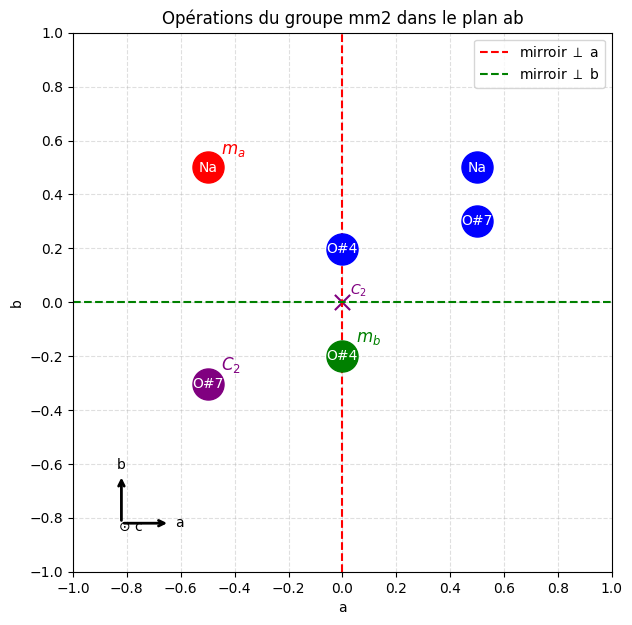

In [219]:
# --- Selection des atoms ---
symmetry_atoms = [atoms_conv[0], atoms_conv[4], atoms_conv[7]]

original_positions = [np.array(atom["pos"][:2], dtype=float) for atom in symmetry_atoms]

# --- Position des atoms symmétriques ---
copied_positions = []

# 1) Reflection 1 : (x,y) -> (-x,y)
p1 = original_positions[0].copy()
p1[0] = -p1[0]
copied_positions.append(p1)

# 2) Reflection 2 : (x,y) -> (x,-y)
p2 = original_positions[1].copy()
p2[1] = -p2[1]
copied_positions.append(p2)

# 3) Rotation C2 : (x,y) -> (-x,-y)
p3 = original_positions[2].copy()
p3[0] = -p3[0]
p3[1] = -p3[1]
copied_positions.append(p3)

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 7))

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_aspect("equal")

ax.set_xticks(np.linspace(-1, 1, 11))
ax.set_yticks(np.linspace(-1, 1, 11))
ax.grid(True, linestyle="--", alpha=0.4)

# Plans Mirroirs
ax.axvline(0, linestyle="--", color="red", linewidth=1.5, label="mirroir $\perp$ a")
ax.axhline(0, linestyle="--", color="green", linewidth=1.5, label="mirroir $\perp$ b")

# Centre de rotation
ax.scatter(0, 0, marker="x", s=120, color="purple")
ax.text(0.03, 0.03, r"$C_2$", color="purple")

# Couleurs
orig_colors = ["blue", "blue", "blue"]
copy_colors = ["red", "green", "purple"]
op_labels = [r"$m_a$", r"$m_b$", r"$C_2$"]
atom_names = ["Na", "O#4", "O#7"]

for i in range(3):
    original_pos = original_positions[i]
    copy_pos = copied_positions[i]

    # Atome original
    ax.scatter(original_pos[0], original_pos[1], s=500, color=orig_colors[i], zorder=3)
    ax.text(original_pos[0], original_pos[1], atom_names[i], ha="center", va="center", color="white")

    # Atomes symmétrique
    ax.scatter(copy_pos[0], copy_pos[1], s=500, color=copy_colors[i], zorder=3)
    ax.text(copy_pos[0], copy_pos[1], atom_names[i], ha="center", va="center", color="white")

    # Label de l'opération
    ax.text(copy_pos[0] + 0.05, copy_pos[1] + 0.05, op_labels[i], color=copy_colors[i], fontsize=12)

draw_lattice_axes(ax, origin=(-0.82, -0.82), length=0.18)

ax.set_xlabel("a")
ax.set_ylabel("b")
ax.set_title("Opérations du groupe mm2 dans le plan ab")
ax.legend()

plt.show()

#### 3. Visualisation de la zone de Brillouin


Première zone de Brillouin
--------------------------


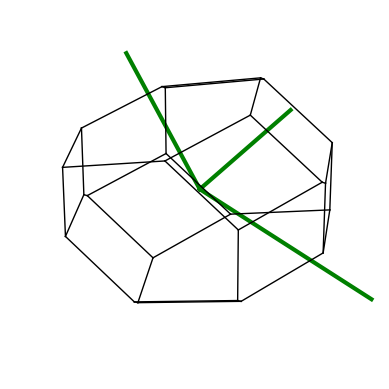

In [220]:
primitive = structure.get_primitive_structure()

print_title("Première zone de Brillouin")

fig = plot_brillouin_zone(structure.lattice.reciprocal_lattice)


#### 4. Diffractograme

<img src="figures/reflection_conditions.png" width="150">  

Source: *International tables for crystallography : Volume A*

In [221]:
def gaussian_broaden(two_theta_sticks, intensities, tt_grid, sigma=0.20):
    """
    Construit une courbe continue à partir des pics discrets de diffraction.
    """
    sigma = sigma / (0.9 * np.sqrt(2.0 * np.log(2.0))) 
    y = np.zeros_like(tt_grid, dtype=float)

    for tt, I in zip(two_theta_sticks, intensities):
        y += I * np.exp(-0.5 * ((tt_grid - tt) / sigma) ** 2)

    return y

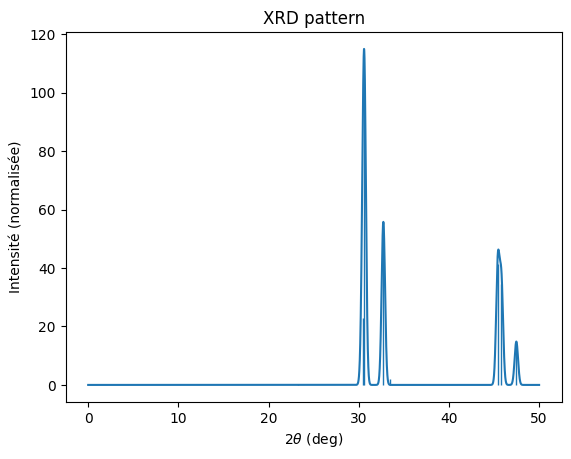

In [222]:
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.diffraction.xrd import XRDCalculator

# On va imposer le groupe à la structure pour réduire les erreurs numériques
sga = SpacegroupAnalyzer(structure, symprec=1e-2, angle_tolerance=5)

# Calcul du pattern de diffraction
wavelength = 1.54060
calc = XRDCalculator(wavelength=wavelength)    
pattern = calc.get_pattern(conventional, scaled=True,two_theta_range=(0,50))

two_theta=np.array(pattern.x)
intensity=np.array(pattern.y)
hkls=np.array(pattern.hkls)

# Masque pour retirer les pics d'intensité trop faible (<2,5%)
treshold = 0.025 * intensity.max()  
mask = intensity > treshold
# Filtrage des pics
two_theta_filtered = two_theta[mask]
intensity_filtered = intensity[mask]
hkls_filtered = hkls[mask]

# Tracer la courbe gausienne continue
tt_grid = np.linspace(0, 50, 6000)  
y_cont = gaussian_broaden(two_theta_filtered, intensity_filtered, tt_grid, sigma=0.20)

plt.figure()
plt.plot(tt_grid, y_cont)                
plt.vlines(two_theta, 0, intensity, linewidth=1)  
plt.xlabel(r"$2\theta$ (deg)")
plt.ylabel("Intensité (normalisée)")
plt.title("XRD pattern")
plt.show()





Le diffractogramme présente les 3 premiers pics aux angles approximatifs suivants: 31, 33, 46 degrés.
\
Grossisons le spectrogramme pour voir plus précisément quels plans (hkl) génèrent ces pics.


Spectrogramme grossi de 30 à 47 degrés
--------------------------------------


/home/qbodart/Git/lmapr1492-project/.venv/lib/python3.14/site-packages/pymatgen/analysis/diffraction/core.py:169: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  self.get_plot(structure, **kwargs).get_figure().show()


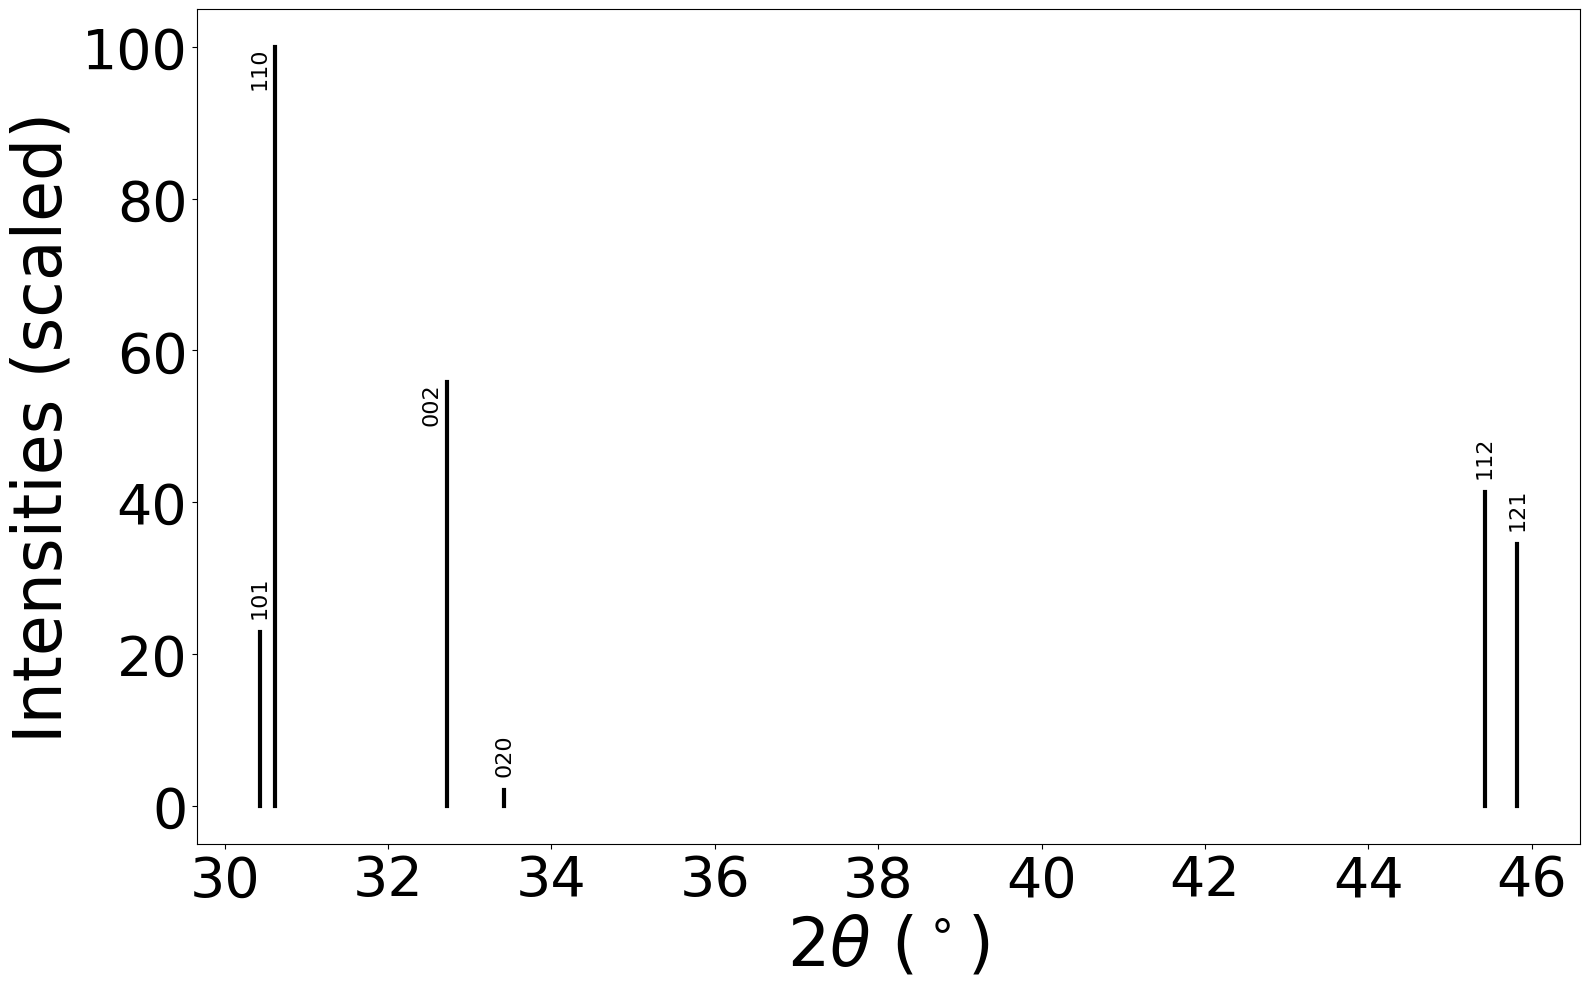

In [223]:
print_title("Spectrogramme grossi de 30 à 47 degrés")
calc.show_plot(conventional, two_theta_range=(30,47))

In [224]:
peaks_data = [
    {
        "Pic": 1,
        "2θ (°)": f"{two_theta_filtered[0]:.2f} / {two_theta_filtered[1]:.2f}",
        "Intensité": f"{intensity_filtered[0]:.2f} / {intensity_filtered[1]:.2f}",
        "hkl": f"{hkls_filtered[0][0]['hkl']} (m={hkls_filtered[0][0]['multiplicity']}) / {hkls_filtered[1][0]['hkl']} (m={hkls_filtered[1][0]['multiplicity']})"
    },
    {
        "Pic": 2,
        "2θ (°)": f"{two_theta_filtered[2]:.2f}",
        "Intensité": f"{intensity_filtered[2]:.2f}",
        "hkl": f"{hkls_filtered[2][0]['hkl']} (m={hkls_filtered[2][0]['multiplicity']})"
    },
    {
        "Pic": 3,
        "2θ (°)": f"{two_theta_filtered[3]:.2f} / {two_theta_filtered[4]:.2f}",
        "Intensité": f"{intensity_filtered[3]:.2f} / {intensity_filtered[4]:.2f}",
        "hkl": f"{hkls_filtered[3][0]['hkl']} (m={hkls_filtered[3][0]['multiplicity']}) / {hkls_filtered[4][0]['hkl']} (m={hkls_filtered[4][0]['multiplicity']})"
    }
]

df_peaks = pd.DataFrame(peaks_data)
display(df_peaks)
print("m: multiplicité")
print("*l'intensité est normalisée avec le pic le plus intense prenant la valeur 100")

,Pic,2θ (°),Intensité,hkl
0,1,30.43 / 30.62,22.90 / 100.00,"(1, 0, 1) (m=4) / (1, 1, 0) (m=4)"
1,2,32.73,55.82,"(0, 0, 2) (m=2)"
2,3,45.42 / 45.82,41.40 / 34.54,"(1, 1, 2) (m=8) / (1, 2, 1) (m=8)"


m: multiplicité
*l'intensité est normalisée avec le pic le plus intense prenant la valeur 100


##### Analyse et interprétation des résultats

Le premier pic est generé par les plans (1,0,1) et (1,1,0). La contribution au pic des deux plans est caractérisée par un angle légèrement différent du fait que $d_{101} < d_{110}$.  
En effet:

In [225]:
def d_hkl(G):
    return 2*np.pi / np.linalg.norm(G)

# Vecteurs du réseau réciproque
K_101 = K_from_hkl(1,0,1,recp_matrix)
K_110 = K_from_hkl(1,1,0,recp_matrix)

d_101 = d_hkl(K_101)
d_110 = d_hkl(K_110)

print(f"d_101: {d_101:.3f}")
print(f"d_110: {d_110:.3f}")

# Calculons la différence d'angle a partir de Bragg
theta_101 = np.rad2deg(np.arcsin(wavelength/(2*d_101)))
theta_110 = np.rad2deg(np.arcsin(wavelength/(2*d_110)))
print(f"Delta 2*theta = {2*(theta_110 - theta_101):.3f}")

print("Nous retrouvons bien la différence d'angle du diffractograme")


d_101: 2.935
d_110: 2.918
Delta 2*theta = 0.186
Nous retrouvons bien la différence d'angle du diffractograme


En ce qui concerne la différence importante d'intensité entre les plans (101) et (110) elle peut être expliquée par l'analyse du facteur de structure de la maille. Avant de calculer celui-ci, nous avons besoins des facteurs de forme atomique.
Nous pouvons les estimer sous l'hypothèse d'une densité électronique sphérique symmétrique autour du noyau en utilisant la formule suivante:
$$
f(|\vec{K}|) = \sum_{i=1}^{4} a_i \exp\left(-b_i \left(\frac{K}{4\pi}\right)^2 \right) + c
$$

avec les valeurs des coefficients:

| Element | a1 | b1 | a2 | b2 | a3 | b3 | a4 | b4 | c |
|--------|----|----|----|----|----|----|----|----|----|
| Na | 4.7626 | 3.285 | 3.1736 | 8.8422 | 1.2674 | 0.3136 | 1.1128 | 129.424 | 0.676 |
| O  | 3.0485 | 13.2771 | 2.2868 | 5.7011 | 1.5463 | 0.3239 | 0.867 | 32.9089 | 0.2508 |
| N  | 12.2126 | 0.0057 | 3.1322 | 9.8933 | 2.0125 | 28.9975 | 1.1663 | 0.5826 | -11.529 |

La formule et les coefficients sont issus de:
[Graz Center of Physics](https://lampz.tugraz.at/~hadley/ss1/crystaldiffraction/atomicformfactors/formfactors.php)


In [226]:
atoms = ["Na", "O", "N"]

a = {
    "Na": [4.7626, 3.1736, 1.2674, 1.1128],
    "O":  [3.0485, 2.2868, 1.5463, 0.867],
    "N":  [12.2126, 3.1322, 2.0125, 1.1663]
}

b = {
    "Na": [3.285, 8.8422, 0.3136, 129.424],
    "O":  [13.2771, 5.7011, 0.3239, 32.9089],
    "N":  [0.0057, 9.8933, 28.9975, 0.5826]
}

c = {
    "Na": 0.676,
    "O": 0.2508,
    "N": -11.529
}

def atomic_form_factor(Knorm, atom):
    """
    Calcule le facteur d'onde atomique sur base de la norme d'un vecteur K 
    du réseau réciproque et de l'atome considéré
    """
    s = Knorm / (4*np.pi)
    
    ai = a[atom]
    bi = b[atom]
    ci = c[atom]

    f = 0
    for i in range(4):
        f += ai[i] * np.exp(-bi[i] * s**2)

    return f + ci

À partir de l'estimation du facteur de forme atomique $f_j(|\mathbf{K}|)$, on peut calculer le facteur de structure de la maille :

$$
S_{\mathbf{G}} = \sum_{j=1}^{N} f_j(|\mathbf{G}|)\, e^{i\,\mathbf{G}\cdot \mathbf{r}_j}
$$

In [227]:
def structure_factor(h,k,l, Knorm, atoms):
    """
    Calcule le facteur de structure pour un vecteur K
    atoms: list de dictionnaires comme: {"element": "Na", "pos"= (x,y,z)}
    """

    S = 0.0 + 0.0j

    for atom in atoms:
        element = atom["element"]
        x,y,z = atom["pos"]

        fj = atomic_form_factor(Knorm, element)
        phase = np.exp(1j * 2 * np.pi * (h*x + k*y + l*z))

        S += fj*phase
        
    return S

print_title("Résultats")
 
S_101 = structure_factor(1,0,1,np.linalg.norm(K_101),atoms_conv)
S_110 = structure_factor(1,1,0,np.linalg.norm(K_110),atoms_conv)

# Multiplicité des pics
m_101 = hkls_filtered[0][0]['multiplicity']
m_110 = hkls_filtered[1][0]['multiplicity']

I_101 = m_101*abs(S_101)**2
I_110 = m_110*abs(S_110)**2

print("S_101 =", S_101)
print("S_110 =", S_110)
print("I_101 =", I_101)
print("I_110 =", I_110)
print(f"Intensité relative de I_101 par rapport à I_110 = {(I_101 / I_110)*100:.1f}")


Résultats
---------
S_101 = (16.688364182023832-1.9857164249280856j)
S_110 = (35.31825413647317-7.105427357601002e-15j)
I_101 = 1129.7782751683405
I_110 = 4989.516300994017
Intensité relative de I_101 par rapport à I_110 = 22.6


L'intensité relative correspond à quelques dizièmes à celle du diffractogramme. La même analyse peut être effectuée pour les autres pics. Nous pouvons par exemple vérifier l'extinction du pic (100) qui ne répond pas à la condition : $$ h = 2n$$

In [228]:
K_100 = K_from_hkl(1,0,0,recp_matrix)
S_100 = structure_factor(1,0,0,np.linalg.norm(K_100), atoms_conv)
I_100 = abs(S_100)**2
print(f"Intensité relative de I_100 par rapport à I_110 = {(I_100 / I_110)*100}")

Intensité relative de I_100 par rapport à I_110 = 2.314824708465453e-31


#### 5. Structure des bandes électroniques

#### 5.1. Graphe


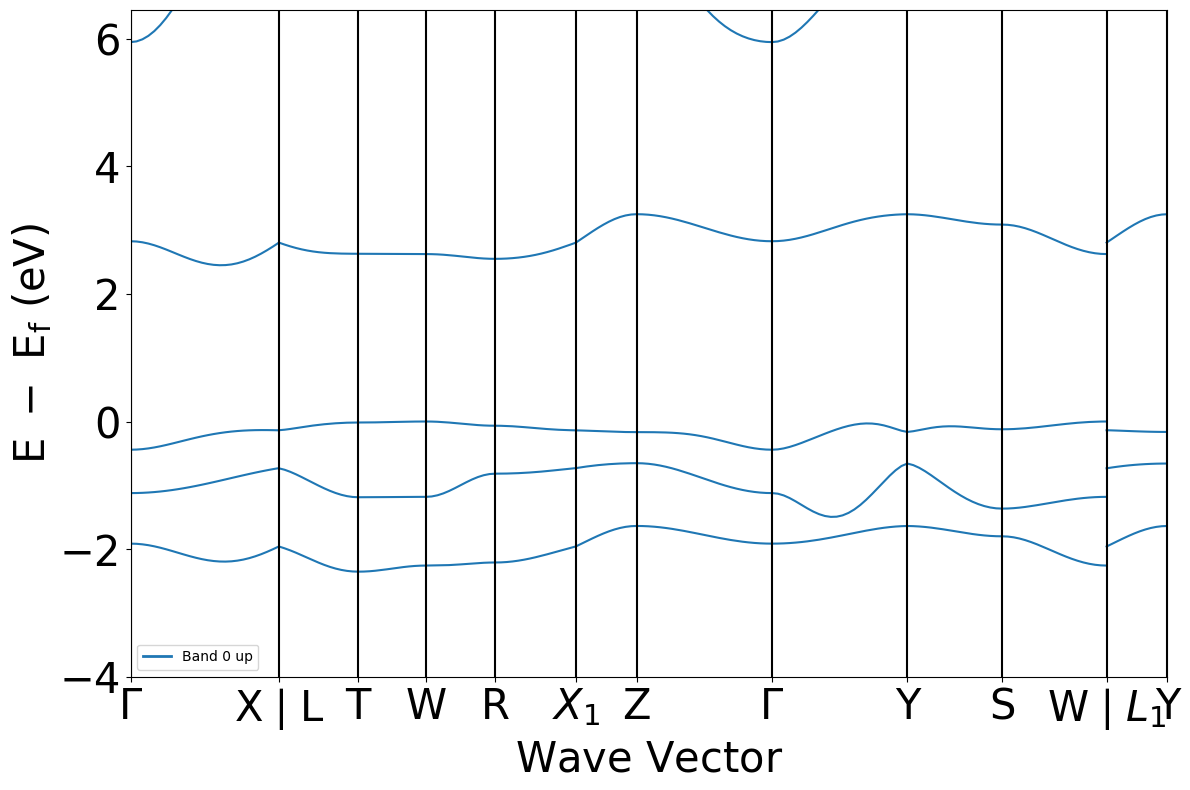

In [229]:
# bandsstructure téléchargé avant
plotter = BSPlotter(bandstructure)
plotter.get_plot()
plt.show()


#### 5.2 Bande Interdite

Largeur de la bande interdite : 2.4493 eV
Type de matériau : Isolant
Type de bande interdite : indirecte (W-(-0.213,0.213,0.213))
Index de la dernière bande de valence : 11
Index de la première bande de conduction : 12


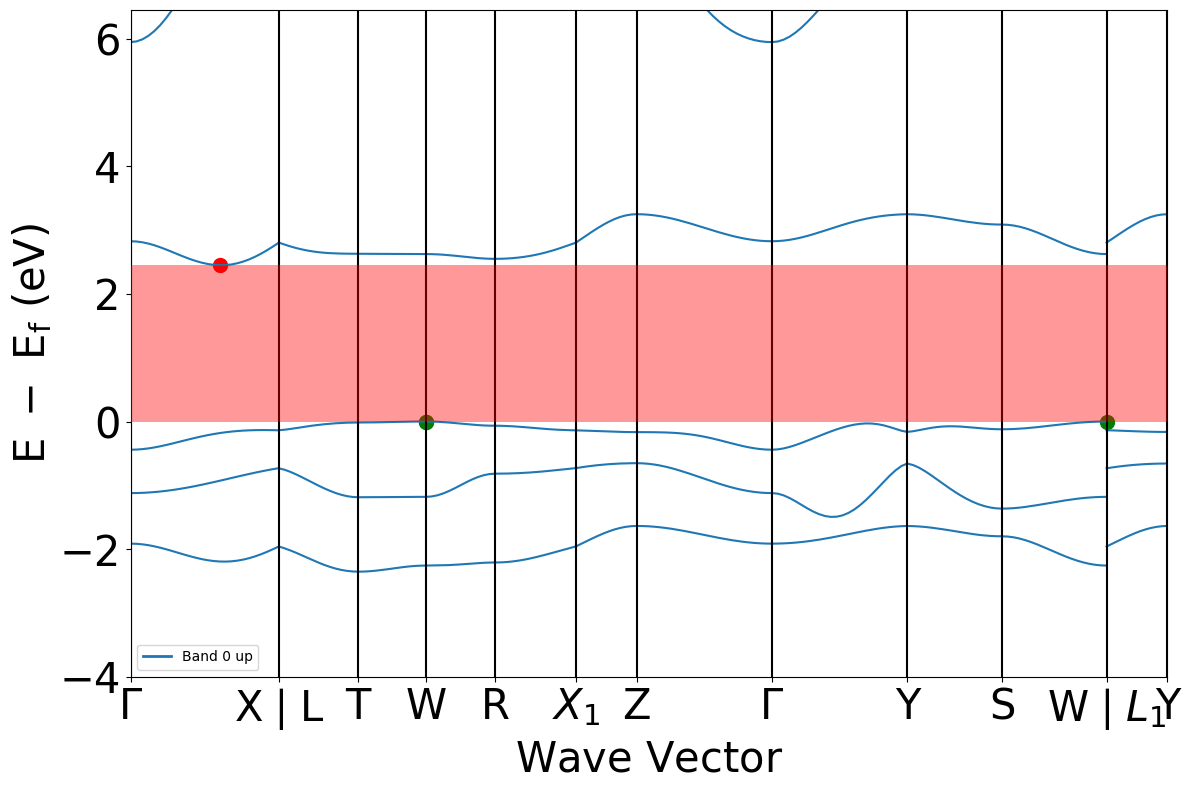

In [230]:
gap = bandstructure.get_band_gap()
gap_width = gap['energy']
gap_trans = gap['transition']
direct = "directe" if gap['direct'] else "indirecte"
mat_type = "Métal" if bandstructure.is_metal() else "Semi-conducteur" if gap_width <= 1.5 else "Isolant"

print(f"Largeur de la bande interdite : {gap_width} eV")
print(f"Type de matériau : {mat_type}")
print(f"Type de bande interdite : {direct} ({gap_trans})")

bsp = BSPlotter(bandstructure)
data = bsp.bs_plot_data()

# Bandes de valences / Bandes de condution
vb, cb, = bandstructure.get_vbm(), bandstructure.get_cbm()
pos_vb, pos_cb = data['vbm'][0], data['cbm'][0]
n_vb, n_cb = vb['band_index'][Spin.up][0], cb['band_index'][Spin.up][0]
print(f"Index de la dernière bande de valence : {n_vb}")
print(f"Index de la première bande de conduction : {n_cb}")

bsp.get_plot(vbm_cbm_marker=True)
ax=plt.gca()
BI=pch.Rectangle((pos_vb[0] - 5 / 2, pos_vb[1]),10,pos_cb[1] - pos_vb[1],linewidth=0,edgecolor=None,facecolor='red',alpha=0.4,zorder=10)
ax.add_patch(BI)
plt.show()

Nous observons dans la figure ci-dessus la bande interdite représentée en rouge, séparent la bande de valence (sous la bande interdite) et la bande de conduction (au-dessus de la bande interdite)

#### 5.3 Direction de dispersion

In [231]:
plot_data = BSPlotter(bandstructure).bs_plot_data(zero_to_efermi=True)
distances = plot_data['distances']
energy = plot_data['energy']

# max and min slopes
mcbs, mvbs = np.inf,np.inf
Mcbs, Mvbs = 0,0
# indexes
mcbi, mvbi, Mcbi, Mvbi = 0,0,0,0

arrow_values = [[],[],[],[]] # max cond, max val, min cond, min val

for i in range(len(distances)):
    # segment distances
    fd, ld = distances[i][0], distances[i][-1]
    delta = ld-fd
    tol = 1e-8
    if abs(delta) < tol:
        continue
    
    # segment energies for valence and conduction bands
    fcbE, lcbE = energy['1'][i][n_cb][0],energy['1'][i][n_cb][-1]
    fvbE, lvbE = energy['1'][i][n_vb][0],energy['1'][i][n_vb][-1]
    
    # slopes
    cbs = (lcbE-fcbE)/delta
    vbs = (lvbE-fvbE)/delta
    
    if abs(cbs) > abs(Mcbs):
        Mcbs = cbs
        Mcbi = i
        arrow_values[0] = [fd, fcbE, delta, lcbE-fcbE]
    
    if abs(vbs) > abs(Mvbs):
        Mvbs = vbs
        Mvbi = i
        arrow_values[1] = [fd, fvbE, delta, lvbE-fvbE]
    
    if abs(cbs) < abs(mcbs):
        mcbs = cbs
        mcbi = i
        arrow_values[2] = [fd, fcbE, delta, lcbE-fcbE]
    
    if abs(vbs) < abs(mvbs):
        mvbs = vbs
        mvbi = i
        arrow_values[3] = [fd, fvbE, delta, lvbE-fvbE]

print(f"Pente minimale de la bande de valence : {mvbs}")
print(f"Pente maximale de la bande de valence : {Mvbs}")
print(f"Pente minimale de la bande de conduction : {mcbs}")
print(f"Pente maximale de la bande de conduction : {Mcbs}")

Pente minimale de la bande de valence : 0.028039188116685022
Pente maximale de la bande de valence : 0.24871647079433049
Pente minimale de la bande de conduction : -0.00857249063440037
Pente maximale de la bande de conduction : 0.8865896470045151


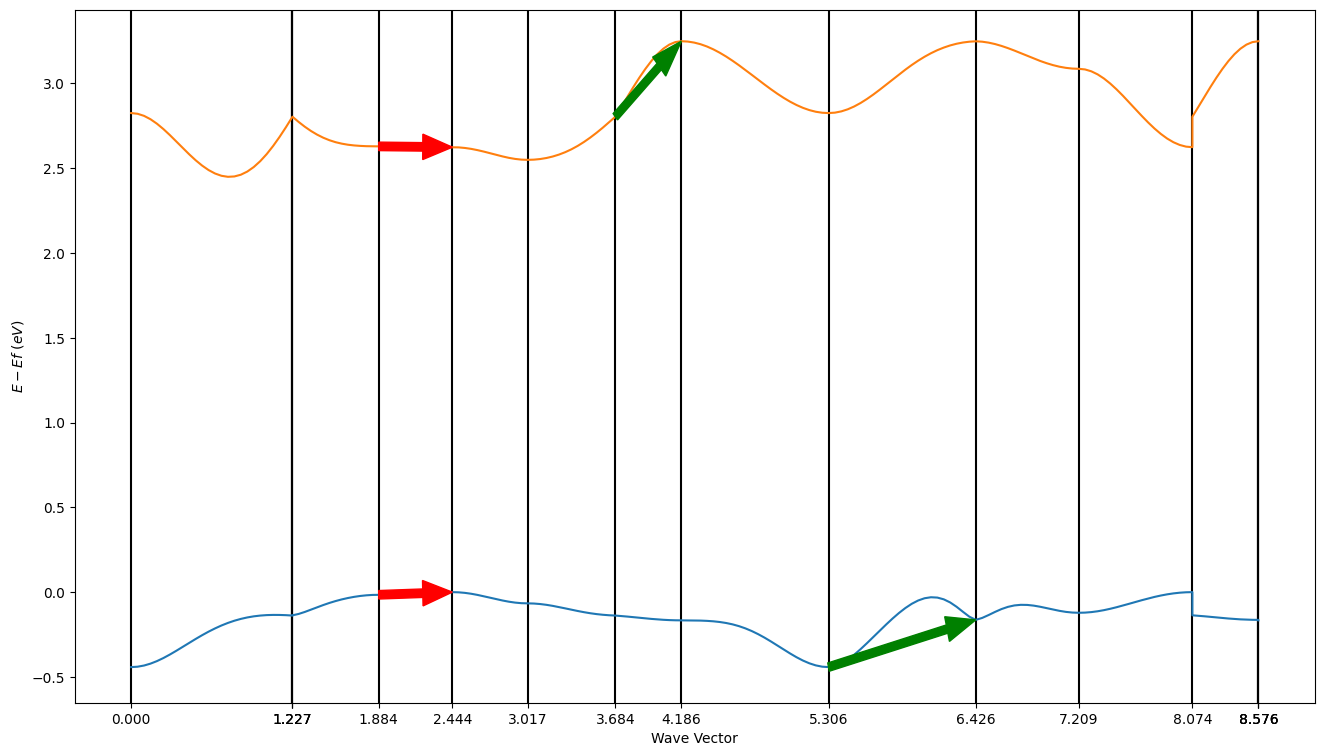

In [232]:
fig, ax = plt.subplots(figsize=(16,9))

# Vertical bars
vaxis = [distances[i][0] for i in range(len(distances))]
vaxis.append(distances[i][-1])

all_distances = np.concatenate(distances)
last_valence_band = np.concatenate([energy['1'][i][n_vb] for i in range(len(distances))])
first_conduction_band = np.concatenate([energy['1'][i][n_cb] for i in range(len(distances))])

ax.set_xticks(vaxis)
#ax.set_xticklabels(['$Γ$', 'L', '$B_1$$|$B', 'Z', '$Γ$', 'X$|$Q', 'F', '$P_1$', 'Z$|$L', 'P']) 
ax.set_xlabel('Wave Vector')
ax.set_ylabel('$E-Ef$ ($eV$)')

for v in vaxis: plt.axvline(v,color='black')

plt.arrow(arrow_values[0][0],arrow_values[0][1],arrow_values[0][2],arrow_values[0][3],zorder=10,length_includes_head=True, width = .05, color='green') # max conduction band slope
plt.arrow(arrow_values[1][0],arrow_values[1][1],arrow_values[1][2],arrow_values[1][3],zorder=10,length_includes_head=True, width = .05, color='green') # max valence band slope
plt.arrow(arrow_values[2][0],arrow_values[2][1],arrow_values[2][2],arrow_values[2][3],zorder=10,length_includes_head=True, width = .05, color='red')   # min conduction band slope
plt.arrow(arrow_values[3][0],arrow_values[3][1],arrow_values[3][2],arrow_values[3][3],zorder=10,length_includes_head=True, width = .05, color='red')   # min valence band slope

plt.plot(all_distances,last_valence_band)
plt.plot(all_distances,first_conduction_band)

plt.show()

BLABLA explication des calculs

#### 5.4 Masse effective

In [233]:
h = 6.62607015e-34 
eV = 1.6022e-19
h_bar = h/(2*np.pi)

k_v, k_c= vb['kpoint'].frac_coords*1e10, cb['kpoint'].frac_coords*1e10
E_v, E_c =vb['energy'], cb['energy']

print(f"Masses effectives :\nDernière bande de valence : {(h_bar**2 * (k_v[0]**2+k_v[1]**2+k_v[2]**2))/(2*abs(E_v)*eV)} [kg] \nPremière bande de conduction : {(h_bar**2 * (k_c[0]**2+k_c[1]**2+k_c[2]**2))/(2*E_c*eV)} [kg]")

Masses effectives :
Dernière bande de valence : 1.5523355278588096e-30 [kg] 
Première bande de conduction : 2.3240299985412364e-31 [kg]


In [234]:
# vérif

Masse effective: blabla

#### 6. Phonons


#### 6.1 Graphe


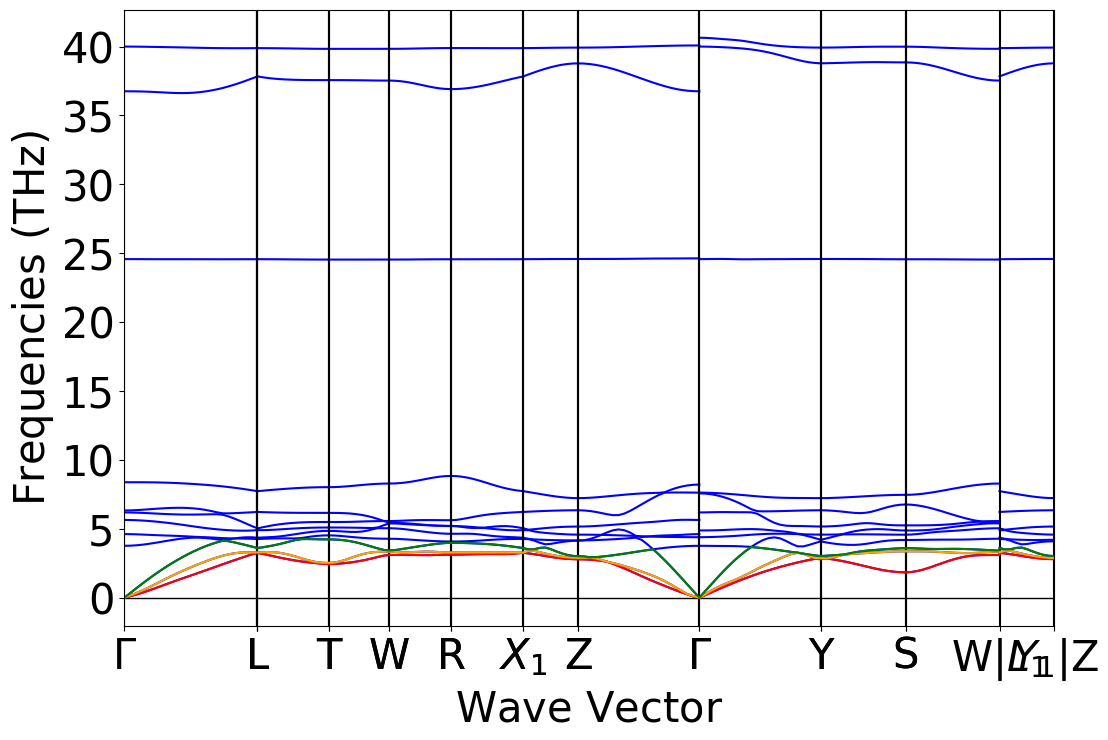

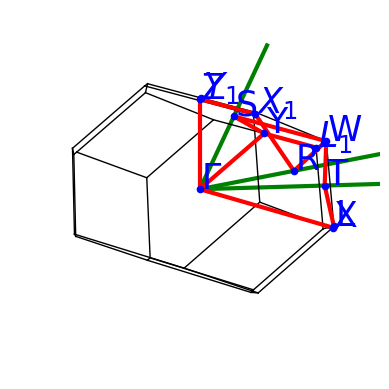

In [235]:
plotter = PhononBSPlotter(phononbandstructure.to_pmg) # ici la classe correspond pas pour le plot -> Ancienne dépendance, il faut d'abord le convertir en objet pymatgen :)
plot_data = plotter.bs_plot_data()

distances = plot_data['distances'] # distances[segment][k_point]
frequency = plot_data['frequency'] # frequency[segment][band(or 'mode')][k_point]

plotter.get_plot()
for i in range(len(distances)):
    plt.plot(distances[i], frequency[i][0], color = 'red')
    plt.plot(distances[i], frequency[i][1], color = 'orange')
    plt.plot(distances[i], frequency[i][2], color = 'green')
plotter.plot_brillouin() 

###########################################################################################################

# #ce que j'ai essayé d'autre (avec chat)

# bands = phononbandstructure.bands 
# qpoints = phononbandstructure.qpoints

# for i in range(3):  # branches acoustiques
#     plt.plot(bands[i])

# plt.title("Branches acoustiques")
# plt.xlabel("Index k")
# plt.ylabel("Fréquence")
# plt.grid()
# plt.show()

#### 6.2 Vitesse du son

In [236]:
# code selon la solution au dessus